### Imports

In [87]:
# Adjust import path
import sys
sys.path.append("../ODEs")
sys.path.append("../")

In [88]:
# Imports
import os
import itertools
import math
import numpy as np
import matplotlib.pyplot as plt

import opinf

import utils
import config_lotka_volterra as config
import step1_generate_data as step1
import step3_estimate as step3
import step4_plot as step4
import numpy as np
import random

seed = 21092023  # Or any integer you prefer

np.random.seed(seed)
random.seed(seed)
%load_ext autoreload
%autoreload 2
import importlib
import sys

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Create Data

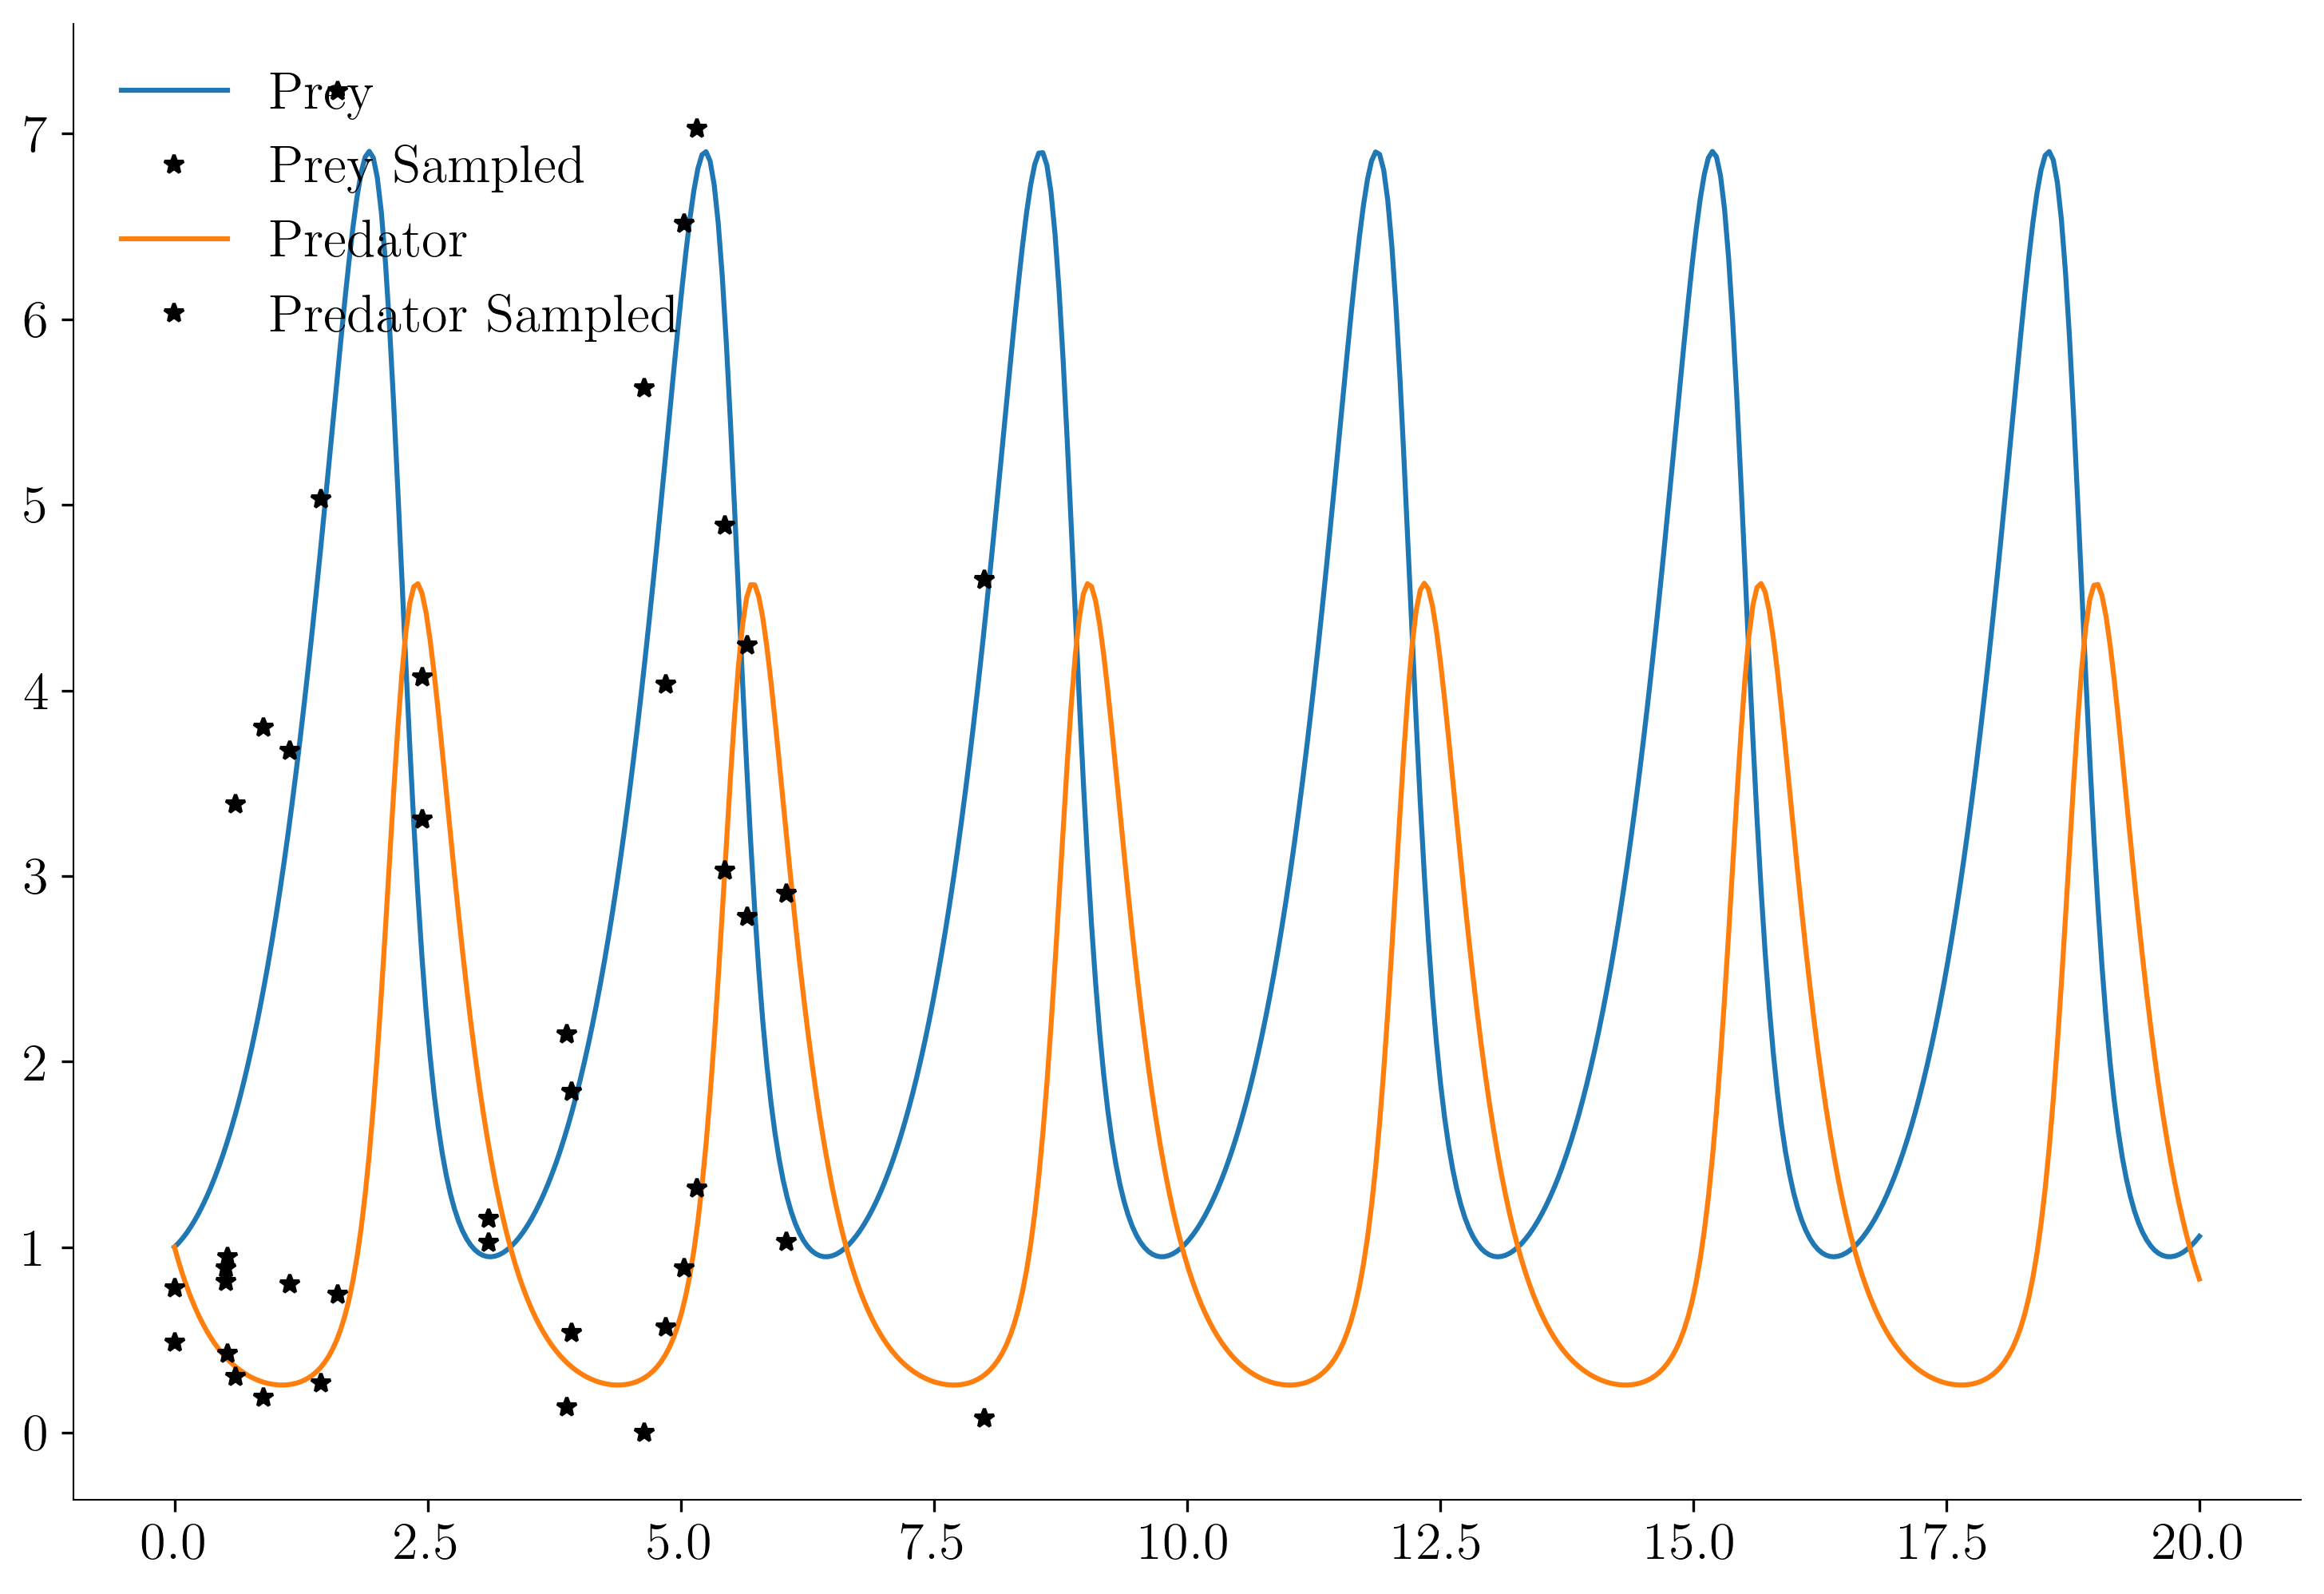

In [89]:
training_span = (0,8)
num_samples = 20
noiselevel = .30
num_regression_points = 300
# Step 1: Generate data ---------------------------------------------------
config.alpha, config.beta, config.gamma, config.delta = 1.5, 1, 3, 1
sampler = step1.TrajectorySampler(
    training_span=training_span,
    num_samples=num_samples,
    noiselevel=noiselevel,
    num_regression_points=num_regression_points,
    synced=True,
    integersonly=False,
    config=config,
)

(
    truthmodel,
    time_domain_prediction,
    true_states,
    time_domains_sampled,
    snapshots_sampled,
) = sampler.sample()
true_parameters = np.copy(truthmodel.parameters)

num_vars = len(true_states)
for i in range(num_vars):
    plt.plot(time_domain_prediction, true_states[i], label='Prey' if i == 0 else 'Predator')
    plt.plot(time_domains_sampled[i], snapshots_sampled[i], 'k*', label='Prey Sampled' if i == 0 else 'Predator Sampled')
plt.legend()
plt.show()

In [90]:
### Standardize the data
y = np.array(snapshots_sampled) # Shape (2,n)
print(y.shape)
time = np.array(time_domains_sampled)[0][:,None] # Shape (20,1)
y_mean = y.mean(axis=1).reshape(2,1).repeat(time.size, axis=1)
y_std = y.std(axis=1).reshape(2,1).repeat(time.size, axis=1)
y_standard = (y - y_mean) / y_std  # Shape (2,n)

(2, 20)


### Train GPS

In [91]:
import jax
import jax.numpy as jnp
from jax import debug
from functools import partial

# 1) RBF kernel
@jax.jit
def rbf_kernel(x1: jnp.ndarray,
               x2: jnp.ndarray,
               lengthscale: float,
               variance: float) -> jnp.ndarray:
    """
    x1: [N, D], x2: [M, D]
    returns K: [N, M] with
    K_ij = variance * exp(-0.5 * ||x1[i]-x2[j]||^2 / lengthscale^2)
    """
    # compute (x1[:,None,:] - x2[None,:,:])**2 summed over last axis
    sqdist = jnp.sum((x1[:, None, :] - x2[None, :, :])**2, axis=-1)
    return variance * jnp.exp(-0.5 * sqdist / (lengthscale**2))


# 2) Log marginal likelihood
@partial(jax.jit, static_argnums=(3,))
def log_marginal_likelihood(params: dict,
                            X: jnp.ndarray,
                            y: jnp.ndarray,
                            standardize: bool) -> float:
    """
    params: {'lengthscale': l, 'variance': σ_f^2, 'noise': σ_n^2}
    X: [N, D], y: [N]
    """
    l = params['lengthscale']
    scale = params['variance']
    noise = params['noise']
    N = X.shape[0]

    K = rbf_kernel(X, X, l, scale) + noise * jnp.eye(N)
    L = jnp.linalg.cholesky(K)

    # Standardize
    if standardize:
        y = (y - jnp.mean(y)) / jnp.std(y)

    # alpha = K^{-1} y via Cholesky solves
    alpha = jax.scipy.linalg.cho_solve((L, True), y)

    log_lik = -0.5 * y @ alpha \
              - jnp.sum(jnp.log(jnp.diag(L))) \
              - 0.5 * N * jnp.log(2 * jnp.pi)
    return log_lik


# 3) Posterior predictive
@partial(jax.jit, static_argnums=())
def gp_predict(params: dict,
               X_train: jnp.ndarray,
               y_train: jnp.ndarray,
               X_test:  jnp.ndarray) -> tuple[jnp.ndarray, jnp.ndarray]:
    """
    Returns predictive mean [M] and covariance [M, M] at X_test.
    mu(x*) = k(x*, x) * [k(x,x) + (sigma**2 * I)]^-1 * y
    cov(x*) = k(x*, x*) - k(x*,x) * [k(x,x) + (sigma**2 * I)]^-1 * k(x,x*)
    """
    l = params['lengthscale']
    scale = params['variance']
    noise = params['noise']

    # Train covariance
    K = rbf_kernel(X_train, X_train, l, scale) + noise * jnp.eye(X_train.shape[0])
    L = jnp.linalg.cholesky(K)

    # Compute α = K^{-1} y_train
    alpha = jax.scipy.linalg.cho_solve((L, True), y_train)

    # Cross-covariances
    K_s = rbf_kernel(X_train, X_test, l, scale)

    # Predictive mean
    mu = K_s.T @ alpha

    # Solve L v = K_s  for v
    v = jax.scipy.linalg.solve_triangular(L, K_s, lower=True)

    # Predictive covariance
    K_ss = rbf_kernel(X_test, X_test, l, scale)
    cov = K_ss - v.T @ v

    return mu, cov

In [92]:
import optax

# Define Bounds
# your bounds
a_l, b_l = 1e-3, 1e2
a_v, b_v = 1e-6, 1e2
a_n, b_n = 1e-8, 1e-0

# 1) Define the raw→[a,b] transform
def bounded(raw, a, b):
    """Map real→(a,b) via sigmoid."""
    return a + (b - a) * jax.nn.sigmoid(raw)

def inv_bounded(f, a, b):
    # f must lie strictly between a and b
    y = (f - a) / (b - a)
    return jnp.log(y / (1 - y))

def raw_to_params(raw):
    return {
      'lengthscale': bounded(raw['u_l'], a_l, b_l),
      'variance':    bounded(raw['u_v'], a_v, b_v),
      'noise':       bounded(raw['u_n'], a_n, b_n),
    }

def params_to_raw(params):
    return{
        'u_l': inv_bounded(params['lengthscale'],    a_l, b_l),
        'u_v': inv_bounded(params['variance'],    a_v, b_v),
        'u_n': inv_bounded(params['noise'],   a_n, b_n),
    }

Iter   0, neg-log-lik = 270.3642
Iter  10, neg-log-lik = 211.5814
Iter  20, neg-log-lik = 170.1310
Iter  30, neg-log-lik = 143.7622
Iter  40, neg-log-lik = 126.3987
Iter  50, neg-log-lik = 113.6969
Iter  60, neg-log-lik = 103.4956
Iter  70, neg-log-lik = 94.7755
Iter  80, neg-log-lik = 87.0915
Iter  90, neg-log-lik = 80.3310
{'lengthscale': Array(0.52797455, dtype=float32), 'variance': Array(1.8353038, dtype=float32), 'noise': Array(0.01994148, dtype=float32)}


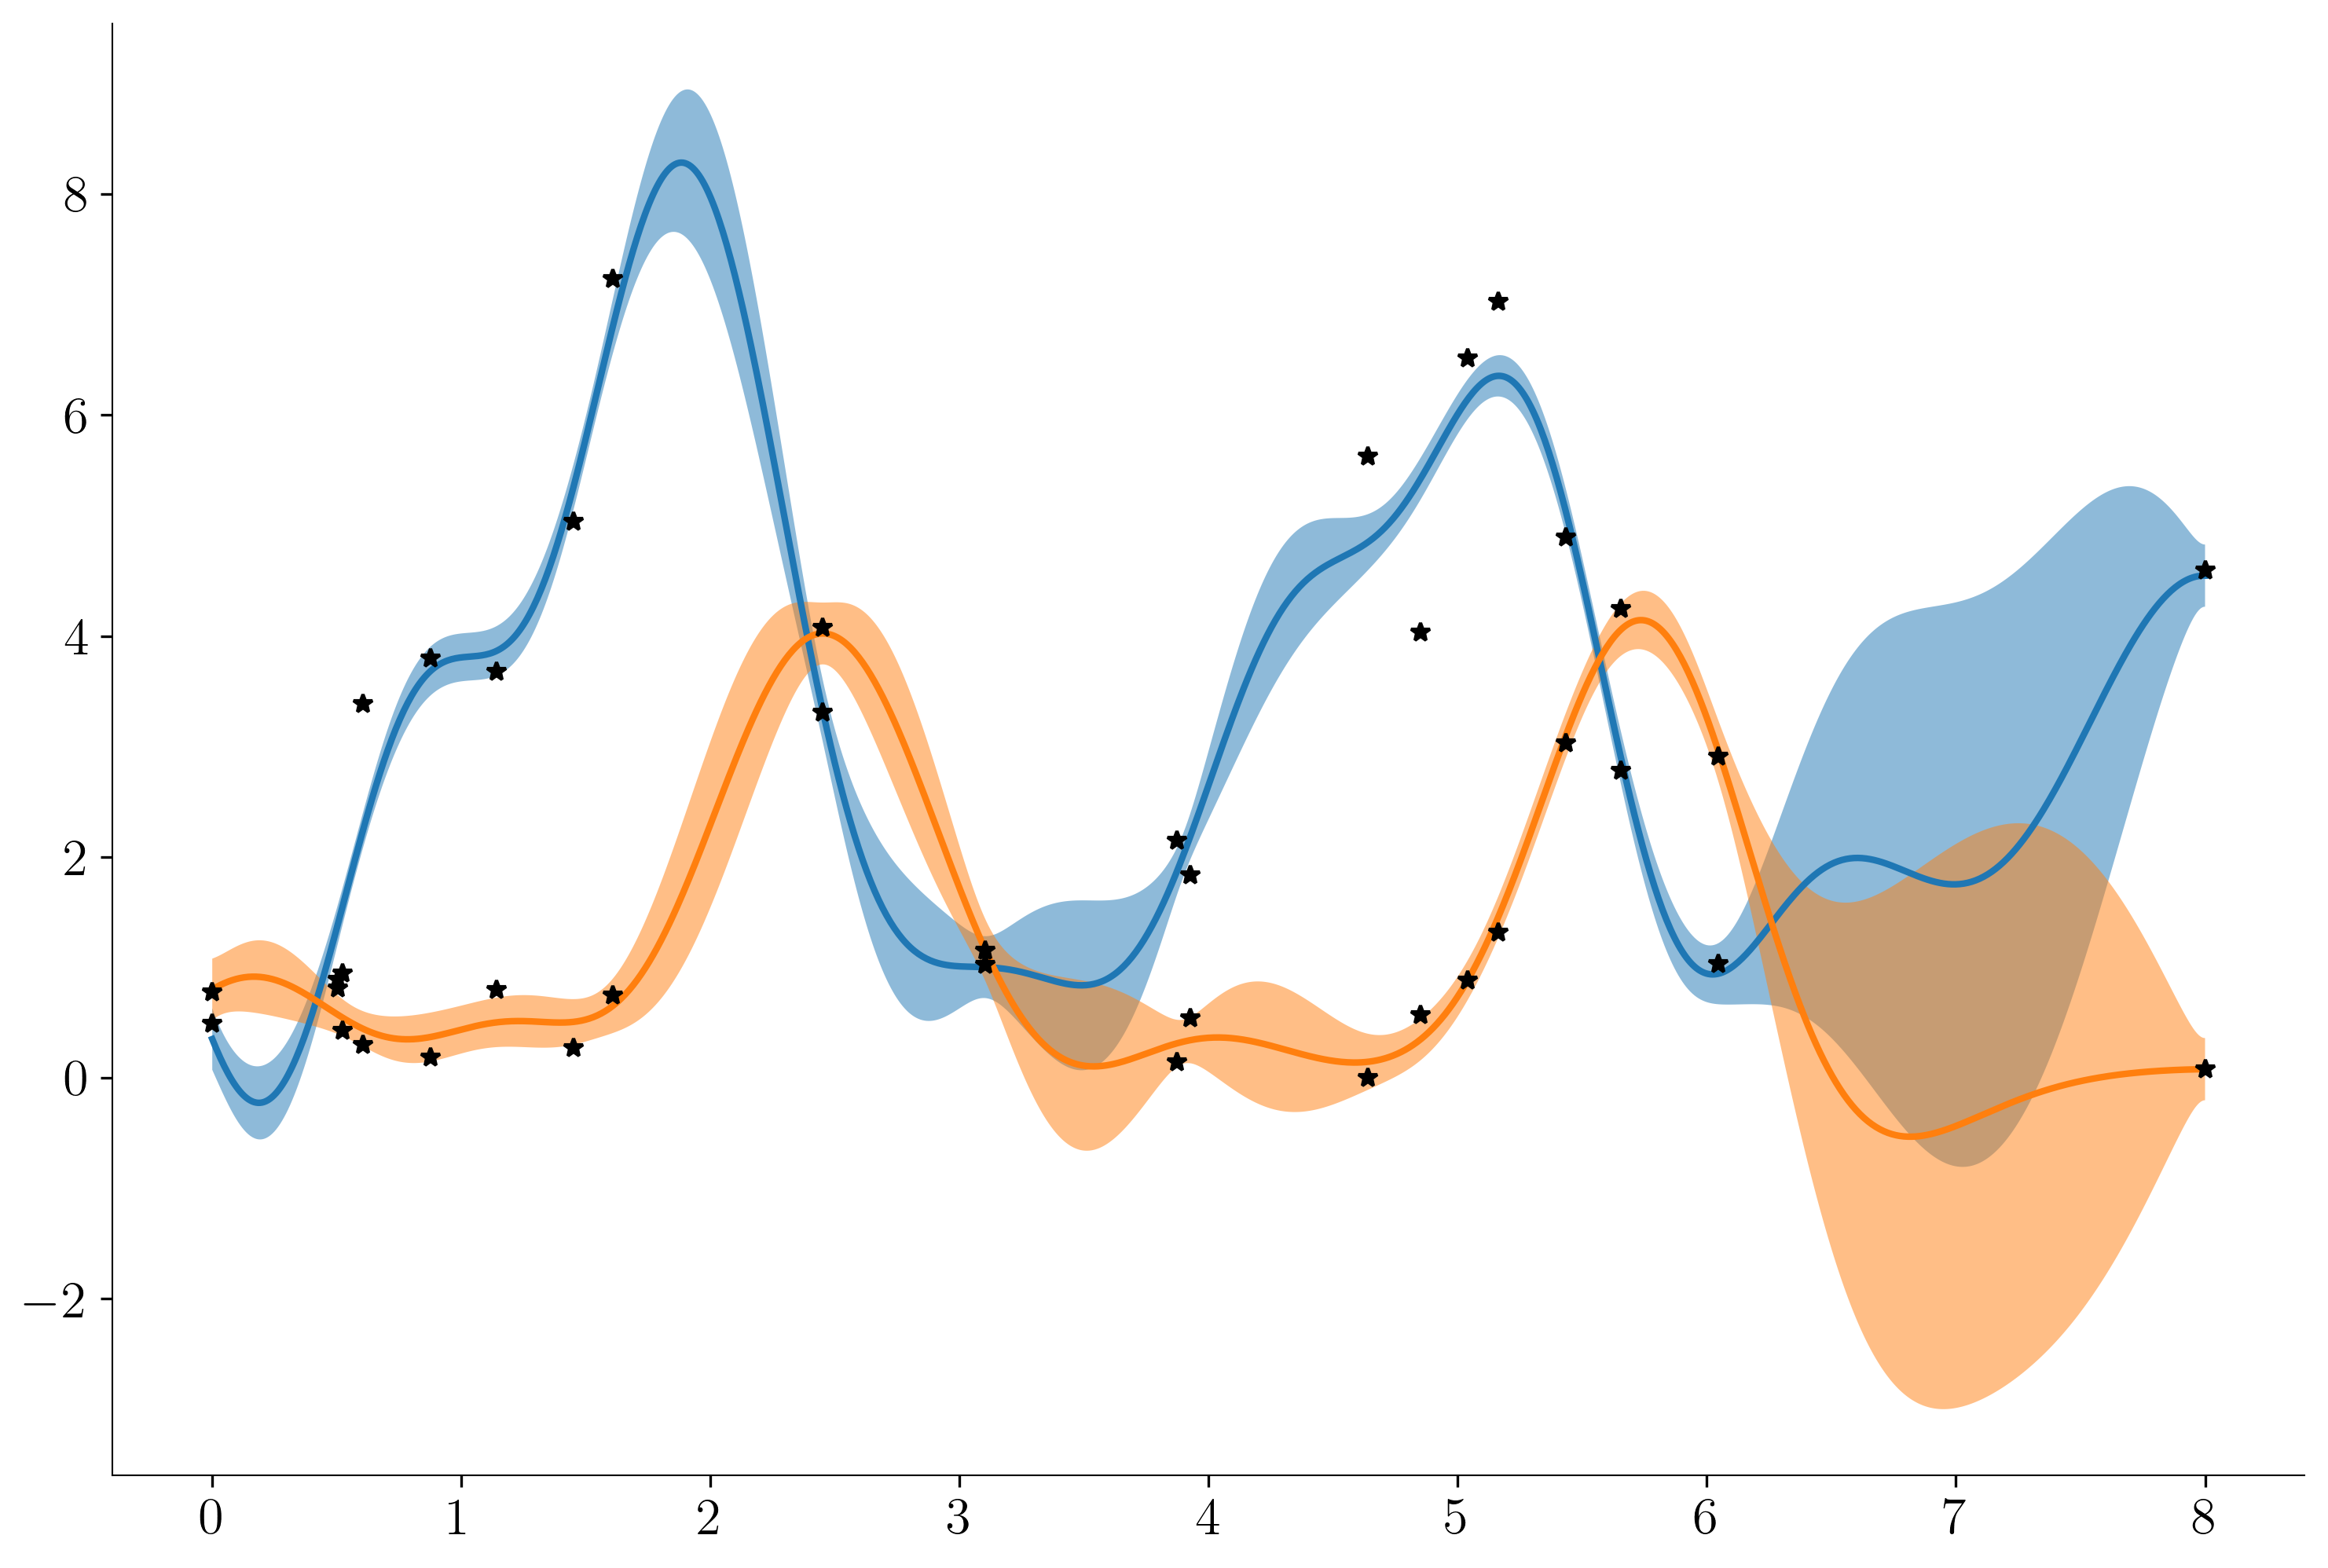

In [93]:
# 2) Initialize raw params (you can pick any real init)
params = {
    'lengthscale': 1.0,    # centered so lengthscale ≈ 1.0
    'variance': 1.0,    # variance ≈ 1.0
    'noise': 1e-2,   # noise ≈ 1e-2
}

raw_params = params_to_raw(params)

optimizer = optax.adam(1e-2)
opt_state = optimizer.init(raw_params)

standardize = True

# 3) One optimization step
def step(raw_params, opt_state, X, y):
    def loss_fn(rp):
        p = raw_to_params(rp)
        loss = 0
        for j in range(y.shape[0]):
            loss += log_marginal_likelihood(p, X, y[j,:], standardize)
        return -1*loss
    loss, grads = jax.value_and_grad(loss_fn)(raw_params)
    updates, opt_state = optimizer.update(grads, opt_state)
    raw_params = optax.apply_updates(raw_params, updates)
    return raw_params, opt_state, loss

# 4) Run your loop exactly as before, but over `raw_params`
for i in range(100):
    raw_params, opt_state, loss = step(raw_params, opt_state, time, y)
    if i % 10 == 0:
        print(f"Iter {i:3d}, neg-log-lik = {loss:.4f}")

# 5) At the end, recover your bounded hyperparams:
final_params = raw_to_params(raw_params)
print(final_params)

Xtest = np.linspace(0,8,1000)[:,None]
for i in range(y.shape[0]):
    post_mu, post_cov = gp_predict(final_params, time, y[i,:], Xtest)
    plt.plot(Xtest, post_mu, lw=2)
    post_std = np.sqrt(np.diag(post_cov))
    plt.fill_between(
        Xtest.flatten(),
        y1 = post_mu - 2*post_std,
        y2 = post_mu + 2*post_std,
        alpha = .5
    )
plt.plot(time, y.T, 'k*')
plt.show()

In [94]:
from jax_gp import GaussianProcess
gp = GaussianProcess(learning_rate=1e-2)
print(y.shape, time.shape)
losses = gp.fit(time, y)

(2, 20) (20, 1)
Iter   0, neg-log-lik = 270.3642
Iter  10, neg-log-lik = 211.5809
Iter  20, neg-log-lik = 170.1310
Iter  30, neg-log-lik = 143.7625
Iter  40, neg-log-lik = 126.3988
Iter  50, neg-log-lik = 113.6973
Iter  60, neg-log-lik = 103.4955
Iter  70, neg-log-lik = 94.7756
Iter  80, neg-log-lik = 87.0918
Iter  90, neg-log-lik = 80.3308
Iter  99, neg-log-lik = 75.0778
Final parameters:
  lengthscale: 0.527975
  variance: 1.835301
  noise: 0.019942


In [95]:
import jax.numpy as jnp

def k(params, t1, t2):
    """
    RBF kernel: variance * exp(-(t1 - t2)^2 / (2 * lengthscale^2))
    """
    l = params['lengthscale']
    var = params['variance']
    return var * jnp.exp(-(t1 - t2)**2 / (2 * l**2))

def c_dash(params, t1, t2):
    """
    d/dt2 of the RBF kernel
    """
    l2 = params['lengthscale']**2
    return (t1 - t2) / l2 * k(params, t1, t2)

def dash_c(params, t1, t2):
    """
    d/dt1 of the RBF kernel
    """
    l2 = params['lengthscale']**2
    return -(t1 - t2) / l2 * k(params, t1, t2)

def c_double_dash(params, t1, t2):
    """
    d^2/dt1/dt2 of the RBF kernel
    """
    l2 = params['lengthscale']**2
    diff = t1 - t2
    return (1 / l2 - diff**2 / l2**2) * k(params, t1, t2)
# ----------------------------------------------------------------------
# helpers
# ----------------------------------------------------------------------

def _flatten_time(t):
    """Return t with shape (n,) no matter if (n,), (n,1) or (1,n) was given."""
    return jnp.ravel(t)

def _rbf_kernel_no_nugget(params, t):
    """
    Full n×n RBF kernel matrix K_ij = variance * exp(-(t_i-t_j)^2 / (2*ell^2)).
    """
    t    = _flatten_time(t)
    diff = t[:, None] - t[None, :]
    ell2 = params["lengthscale"] ** 2
    return params["variance"] * jnp.exp(-diff**2 / (2.0 * ell2))

# ----------------------------------------------------------------------
# public API – each returns an (n, n) array
# ----------------------------------------------------------------------

def get_c_phi(params, t, nugget=1e-4):
    """Kernel matrix plus nugget on the diagonal."""
    kmat = _rbf_kernel_no_nugget(params, t)
    return kmat + nugget * jnp.eye(kmat.shape[0])

def get_c_phi_dash(params, t):
    """Derivative with respect to the second time argument (dt2)."""
    t    = _flatten_time(t)
    diff = t[:, None] - t[None, :]
    ell2 = params["lengthscale"] ** 2
    return (diff / ell2) * _rbf_kernel_no_nugget(params, t)

def get_dash_c_phi(params, t):
    """Derivative with respect to the first time argument (dt1)."""
    return -get_c_phi_dash(params, t)

def get_c_phi_double_dash(params, t):
    """Second mixed derivative with respect to both time arguments."""
    t    = _flatten_time(t)
    diff = t[:, None] - t[None, :]
    ell2 = params["lengthscale"] ** 2
    return (1.0 / ell2 - diff**2 / ell2**2) * _rbf_kernel_no_nugget(params, t)

### Run Metropolis Hastings

In [96]:
import numpy as np

from DensityCalculation import getAs, getDs, getLambdaStars, calculateLogDensity
from MCMCSampler import MCMCWithBounds
from LotkaVolterra import LotkaVolterra as exp     # experiment model

# ------------------------------------------------------------------
# 0. User-adjustable flags
# ------------------------------------------------------------------
STANDARDIZE  = True       # if False we only mean-correct (normalise)
NORMALIZE    = not STANDARDIZE
GP_INIT      = True
BLOCK_NEG    = False
DEBUG        = False

# ------------------------------------------------------------------
# 1.  Data layout fix  (make y = (T, D))
# ------------------------------------------------------------------
if y.shape[0] < y.shape[1]:
    y = y.T
T, D = y.shape

# ------------------------------------------------------------------
# 2.  Basic constants
# ------------------------------------------------------------------
nODEParams   = 4
kernels      = [4, 2]             # <-- place-holders for the single-kernel case
time         = time
experiment   = exp()

# ------------------------------------------------------------------
# 3.  γ  (derivative noise)  – correct scalar/vector handling
# ------------------------------------------------------------------
gammaValue = 1e-3                 # << you said this is the intended value
gammas     = gammaValue * np.ones(len(kernels))   # shape = (D,)

# ------------------------------------------------------------------
# 4.  Per-state mean / std  (respect flags)
# ------------------------------------------------------------------
mean_vec = np.mean(y, axis=0)
std_vec  = np.std(y,  axis=0)

if STANDARDIZE:
    # full standardisation
    mean = np.repeat(mean_vec, T)
    std  = np.repeat(std_vec,  T)
elif NORMALIZE:
    # mean-centre only
    mean = np.repeat(mean_vec, T)
    std  = np.ones_like(mean)     # leave scale untouched
else:
    # no transformation
    mean = np.zeros(T * D)
    std  = np.ones_like(mean)

# ------------------------------------------------------------------
# 5.  Convenience matrices
# ------------------------------------------------------------------
meanMatrix = mean.reshape((T, D), order='F')
stdMatrix  = std.reshape((T, D), order='F')


In [97]:
# ------------------------------------------------------------------
# 0.  θ initialisation and scaling
# ------------------------------------------------------------------
thetaMagnitudes = np.zeros(nODEParams)      # keep simple for now
totalLength     = y.size + nODEParams
x0              = np.ones(totalLength)

theta0 = np.abs(np.random.randn(nODEParams))   # random positive start
x0[-nODEParams:] = theta0                      # *un-scaled* (opt variables)

# ------------------------------------------------------------------
# 1.  GP-posterior or observation initialiser for the states
# ------------------------------------------------------------------
stdY   = (y - meanMatrix) / stdMatrix       # shape (T, D)
fullMu = np.zeros_like(y)

if GP_INIT:
    print("initialise with GP posterior")
    CPhi  = get_c_phi(final_params, time)
    print(CPhi.shape)
    sigma = np.asarray(final_params['noise']).reshape(1, 1)

    for i in range(D):
        Yi     = stdY[:, i]
        GPmean = np.linalg.solve(CPhi + sigma * np.eye(CPhi.shape[0]),
                                 CPhi.dot(Yi))
        fullMu[:, i] = GPmean
else:
    print("initialise with observations")
    fullMu = stdY                                # already in standard space

# flatten into x0
x0[:y.size] = fullMu.reshape(-1, order='F')

# ------------------------------------------------------------------
# 2.  Bounds  (use the experiment’s bounds **as-is**)
# -----------------------------i-------------------------------------
xmin, xmax = experiment.getBounds(y.size, nODEParams, x0=x0)

if BLOCK_NEG:
    # forbid negative (de-standardised) states
    newZeros = (1e-10 * np.ones_like(mean) - mean) / std
    for i in range(y.size):
        xmin[i] = max(xmin[i], newZeros[i])

bounds = list(zip(xmin, xmax))

# ensure starting point is inside the box
for i, (lo, hi) in enumerate(bounds):
    if x0[i] < lo:
        x0[i] = lo + (hi - lo) * 1e-5
    elif x0[i] > hi:
        x0[i] = hi - (hi - lo) * 1e-5

# ------------------------------------------------------------------
# 3.  Log-density wrapper (state-then-param split)
# ------------------------------------------------------------------
def _log_density(opt_vec):
    states_std = opt_vec[:-nODEParams]
    params     = opt_vec[-nODEParams:] * (10 ** thetaMagnitudes)
    return -2 * states_std.size * calculateLogDensity(
        y         = y.reshape(-1, order='F'),
        x         = states_std,
        CPhis             = [CPhi] * D,         # single-kernel setup
        sigmas         = [sigma] * D,
        f                 = experiment.f,
        theta         = params,
        As                = getAs([get_c_phi_dash(final_params, time)] * D,
                                  [get_dash_c_phi(final_params, time)] * D,
                                  [CPhi] * D,
                                  [get_c_phi_double_dash(final_params, time)] * D),
        Ds                = getDs([get_dash_c_phi(final_params, time)] * D,
                                  [CPhi] * D),
        Lambdas           = getLambdaStars(gammas, T),
        mean              = mean,
        std               = std
    )

# ------------------------------------------------------------------
# 4.  Proposal stds – start conservative, tune later
# ------------------------------------------------------------------
# propStds = np.ones_like(x0) * 0.02   # ≈5 % moves in standard space
propStds = np.ones_like(x0) * 0.02   # ≈5 % moves in standard space

# ------------------------------------------------------------------
# 5.  MCMC
# ------------------------------------------------------------------
nSamples, nBurnin = 80, 80
print("Starting MCMC", nSamples, nBurnin)

samples, acc, rej = MCMCWithBounds(
    logTarget    = _log_density,
    xInit        = x0,
    proposalStds = propStds,
    lowerBounds  = xmin,
    upperBounds  = xmax,
    nSamples     = nSamples,
    nBurnin      = nBurnin,
)

print("Done with MCMC")

# ------------------------------------------------------------------
# 6.  Posterior means → de-standardise back to original units
# ------------------------------------------------------------------
postMean  = samples.mean(axis=0)
statesStd = postMean[:-nODEParams].reshape((T, D), order='F')
params    = postMean[-nODEParams:] * (10 ** thetaMagnitudes)

states = statesStd * stdMatrix + meanMatrix

print("Inferred parameters:", params)

initialise with GP posterior
(20, 20)
Starting MCMC 80 80


100%|██████████| 160/160 [00:11<00:00, 14.34it/s]

Done with MCMC
Inferred parameters: [1.55903382 1.11535387 1.85169159 0.74637835]


In [98]:
from nuts import calculateLogDensity
import numpyro
import numpyro.distributions as dist
xmin, xmax = jnp.array(xmin), jnp.array(xmax)
jax_y = jnp.array(y)
jax_CPhi = jnp.array(CPhi)
jax_sigma = jnp.array(sigma) 
jax_As = jnp.array(getAs([get_c_phi_dash(final_params, time)] * D,
                            [get_dash_c_phi(final_params, time)] * D,
                            [CPhi] * D,
                            [get_c_phi_double_dash(final_params, time)] * D),)
jax_Lambdas = jnp.array(getLambdaStars(gammas, T)) 

jax_mean = jnp.array(mean)
jax_std = jnp.array(std)

def jax_f(x, theta):
        """
        \dot{x_0} = x_0 * (theta_0 - theta_1*x_1)
        \dot{x_1} = -x_1 * (theta_2 - theta_3*x_0)
        will return derivatives in a vector
        """
        firstODE = x[0]*(theta[0] - theta[1]*x[1])
        secondODE = -x[1]*(theta[2] - theta[3]*x[0])
        return jnp.array([firstODE, secondODE])

def jax_getDs(DashCs, CPhis):
    """
    each entry represents a state
    
    Parameters
    ----------
    DashCs:         list of matrices of shape nTime x nTime
    CInvs:          list of matrices of shape nTime x nTime

    Returns
    ----------
    D:  list of matrices of shape nTime x nTime
        each entry represents one state
    """
    D = []
    for i in jnp.arange(len(DashCs)):
        def getProdWithD(x, index=i):
            """
            defines a function to get a product of a vector with the matrix D
            """
            return jnp.dot(DashCs[index],
                          jnp.linalg.solve(CPhis[index], x)
                          )
        D.append(getProdWithD)
    return D

jax_Ds = jax_getDs([get_dash_c_phi(final_params, time)] * D,
                    [CPhi] * D)

def model():
        # Prior for parameters (unconstrained to match original implementation)
        # We'll handle constraints through the transform
        states_std_flat = numpyro.sample(
            "states_std",
            dist.Uniform(jnp.array(xmin[:-nODEParams]), jnp.array(xmax[:-nODEParams])).to_event(1)
        )
        
        # Prior for ODE parameters
        params_unconstrained = numpyro.sample(
            "params_unconstrained",
            dist.Uniform(jnp.array(xmin[-nODEParams:]), jnp.array(xmax[-nODEParams:])).to_event(1)
        )
        
        # No need for thetaMagnitudes scaling since we're directly defining priors
        params = params_unconstrained  # * (10 ** thetaMagnitudes) if needed
        
        # Calculate log density using JAX-compatible functions
        # Reshape y to match original calculation
        jax_y_reshaped = jnp.reshape(jax_y, (-1,), order='F')
        
        log_density = -calculateLogDensity(
            y=jax_y_reshaped,
            x=states_std_flat,
            CPhis=[jax_CPhi] * D,  # Single-kernel setup
            sigmas=[jax_sigma] * D,
            f=jax_f,
            theta=params,
            As=jax_As,
            Ds=jax_Ds,
            Lambdas=jax_Lambdas,
            mean=jax_mean,
            std=jax_std
        )
        
        # Add the likelihood term
        numpyro.factor("likelihood", log_density)


from numpyro.infer import MCMC, NUTS
import jax.random as random

# 1) Create the NUTS kernel
nuts_kernel = NUTS(model)

# 2) Wrap in MCMC, tuning the number of warmup and samples
mcmc = MCMC(nuts_kernel,
            num_warmup=10000,
            num_samples=10000,
            num_chains=4)        # you can run multiple chains in parallel

# 3) Run it with a JAX PRNG key
rng_key = random.PRNGKey(0)
mcmc.run(rng_key)

# 4) Extract posterior samples
posterior_samples = mcmc.get_samples()
print(posterior_samples["params_unconstrained"].shape)  # e.g. (2000*4, n_params

<>:18: SyntaxWarning: invalid escape sequence '\d'
<>:18: SyntaxWarning: invalid escape sequence '\d'
/var/folders/z5/hb7nxgp524b67trvdyv41twh0000gn/T/ipykernel_67931/2080715042.py:18: SyntaxWarning: invalid escape sequence '\d'
  """
/var/folders/z5/hb7nxgp524b67trvdyv41twh0000gn/T/ipykernel_67931/2080715042.py:102: UserWarning: There are not enough devices to run parallel chains: expected 4 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(4)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(nuts_kernel,
sample:  58%|█████▊    | 11531/20000 [00:11<00:08, 971.03it/s, 31 steps of size 1.14e-01. acc. prob=0.92] 
/var/folders/z5/hb7nxgp524b67trvdyv41twh0000gn/T/ipykernel_67931/2080715042.py:18: SyntaxWarning: invalid escape sequence '\d'
  """


KeyboardInterrupt: 

In [ ]:
theta = posterior_samples['params_unconstrained'].mean(axis=0)
theta

Array([1.5076541 , 1.0705144 , 2.579179  , 0.91663533], dtype=float32)

### Plotting

In [ ]:
# theta = params
config.alpha, config.beta, config.delta, config.gamma = theta[0], theta[1], theta[3], theta[2]
print(config.alpha, config.beta, config.gamma, config.delta)
sampler = step1.TrajectorySampler(
    training_span=training_span,
    num_samples=num_samples,
    noiselevel=noiselevel,
    num_regression_points=num_regression_points,
    synced=True,
    integersonly=False,
    config=config,
)

(
    truthmodel,
    time_domain_prediction,
    true_states_not,
    time_domains_sampled,
    snapshots_sampled,
) = sampler.sample()

1.5076541 1.0705144 2.579179 0.91663533


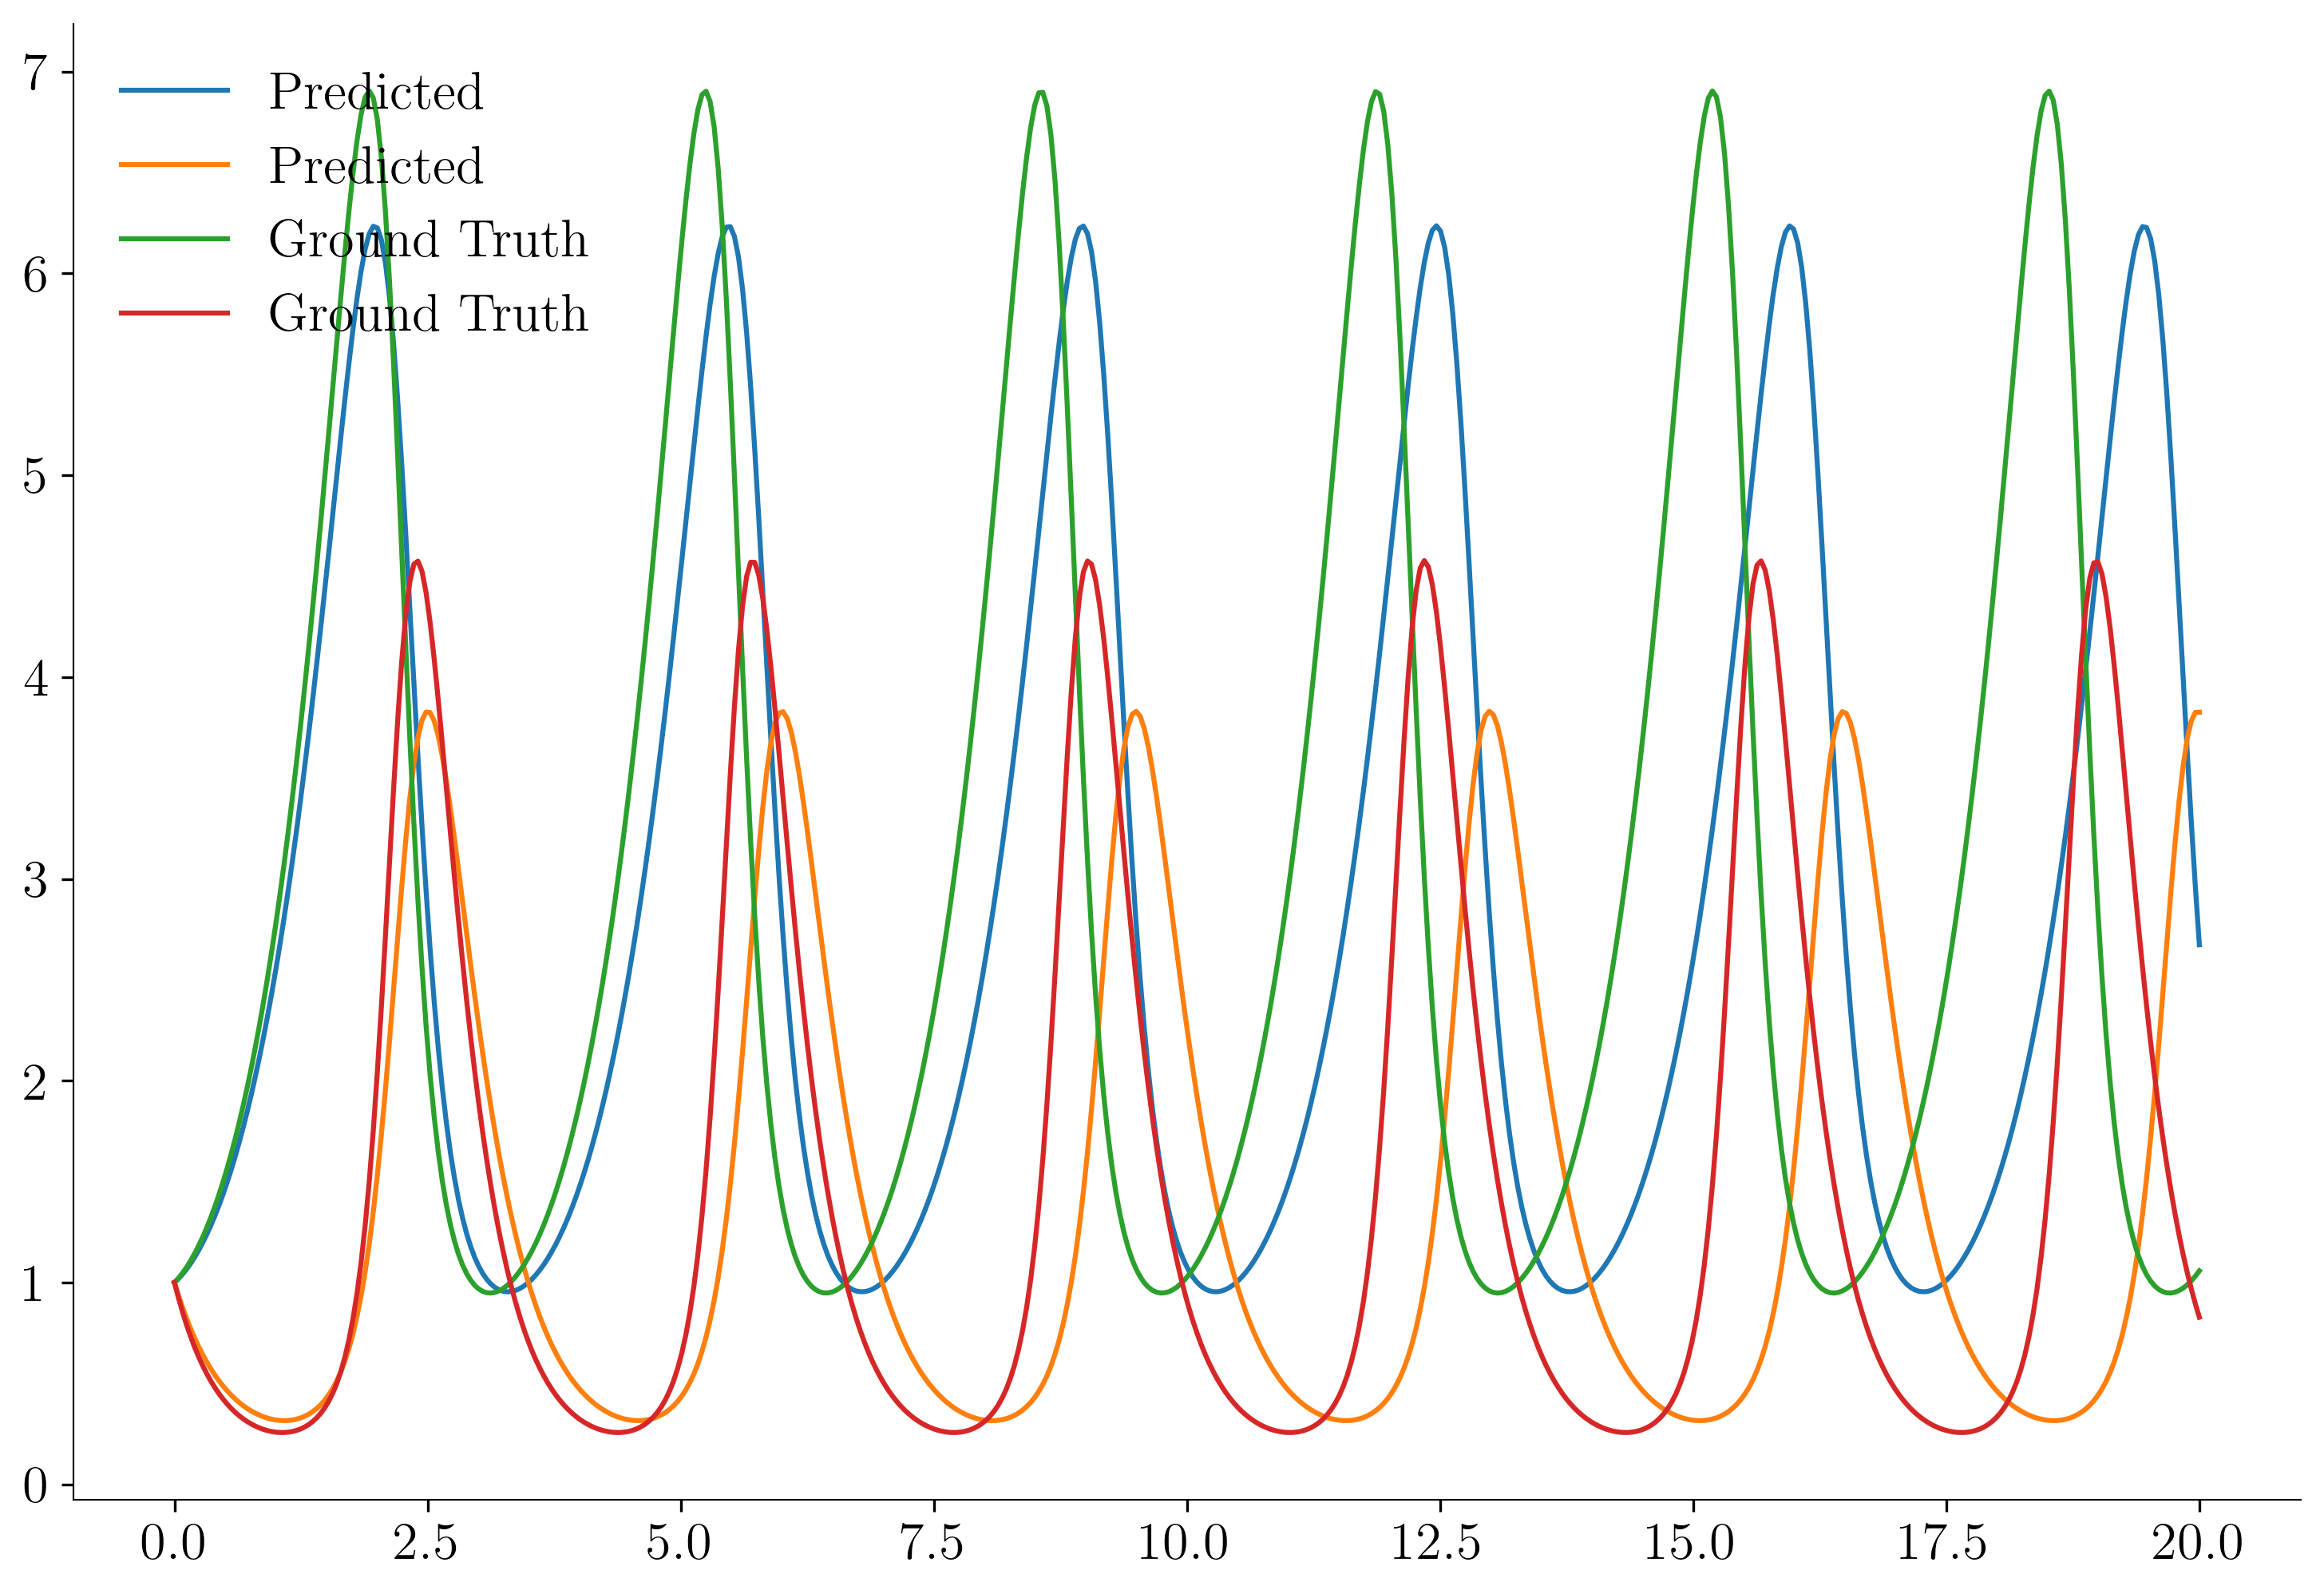

In [ ]:
plt.plot(time_domain_prediction, true_states_not.T, label='Predicted')
plt.plot(time_domain_prediction, true_states.T, label='Ground Truth')
plt.legend()
plt.show()